In [34]:
from dataclasses import replace
import tabulate

from config.experiment import ExperimentConfig
from experiments import load_config
from config.task import generate_task_configs
from utils.plot import Metric, plot_metrics_vs_perturbation, get_metrics, shorten_model_name, strip_hf_org, PlotFilter

In [35]:
def get_config(cfg_name: str) -> ExperimentConfig:
    exp_cfg = load_config(cfg_name)

    return ExperimentConfig(
        train = replace(exp_cfg.train, save_folder = exp_cfg.train.save_folder.parent / "paper"),
        eval = replace(exp_cfg.eval, results_folder = exp_cfg.eval.results_folder.parent / "paper"),
    )

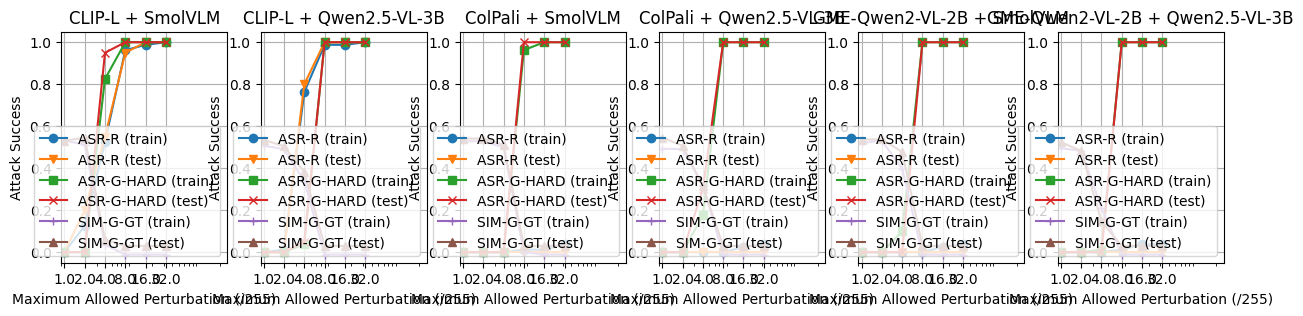

In [36]:
exp_config = get_config("paper_perturbation_plot")

plot_metrics_vs_perturbation(exp_config, metrics_to_show=[Metric.RETRIEVAL_ASR_TRAIN, Metric.RETRIEVAL_ASR_TEST, Metric.GENERATION_ASR_EXACT_TRAIN, Metric.GENERATION_ASR_EXACT_TEST, Metric.GENERATION_ACC_EMBED_GT_TRAIN, Metric.GENERATION_ACC_EMBED_GT_TEST], ret_topk_idx=0, gen_topk_idx=0)

In [37]:
# exp_config = get_config("perturbation_plot_targeted")
#
# plot_metrics_vs_perturbation(exp_config, metrics_to_show=[Metric.RETRIEVAL_ASR_TRAIN, Metric.RETRIEVAL_ASR_TEST,
#                                                           Metric.GENERATION_ASR_EXACT_TRAIN,
#                                                           Metric.GENERATION_ASR_EXACT_TEST,
#                                                           Metric.GENERATION_ACC_EMBED_GT_TRAIN,
#                                                           Metric.GENERATION_ACC_EMBED_GT_TEST], ret_topk_idx=0,
#                              gen_topk_idx=0)

In [38]:
def make_all_metric_table(config_name: str, metrics_to_show:list[Metric]|None=None, row_filter = None):
    exp_config = get_config(config_name)
    if metrics_to_show is None:
        metrics_to_show = [m for m in Metric]

    task_configs = generate_task_configs(exp_config, include_eval=True)

    table = []
    for task_config in task_configs:
        row = {
            "dataset": strip_hf_org(task_config.ds_name),
        }
        if not exp_config.eval.test_gpt_attack:
            row["embedder"] = shorten_model_name(task_config.model_name_embs[0]) if len(task_config.model_name_embs) == 1 else "+".join([shorten_model_name(m) for m in task_config.model_name_embs])
            if task_config.vlm:
                row["vlm"] = shorten_model_name(task_config.vlm.models[0]) if len(task_config.vlm.models) == 1 else "+".join([shorten_model_name(m) for m in task_config.vlm.models])
                if len(exp_config.train.vlm.gen_topk_list) > 1:
                    row["vlm topk"] = task_config.vlm.gen_topk
        if len(exp_config.train.emb_train_loss_type_list) > 1:
            row["emb train loss"] = task_config.emb_train_loss_type
        if len(exp_config.train.attack_mask_list) > 1:
            row["attack mask"] = task_config.attack_mask.name
        if task_config.eval_emb_name:
            row["eval emb"] = shorten_model_name(task_config.eval_emb_name)
        if task_config.eval_vlm_name:
            row["eval vlm"] = shorten_model_name(task_config.eval_vlm_name)

        if task_config.judge:
            row["judge"] = shorten_model_name(task_config.judge.model_name)
        if task_config.eval_jdg_name:
            row["eval judge"] = shorten_model_name(task_config.eval_jdg_name)
        metrics, _ = get_metrics(
            exp_config=exp_config,
            task_config=task_config,
            metrics_to_show=metrics_to_show,
        )
        row.update(metrics)
        table.append(row)
    if row_filter:
        table = [row for row in table if row_filter(row)]
    # return tabulate.tabulate(table, headers="keys", tablefmt="latex", showindex="never")
    return tabulate.tabulate(table, headers="keys", tablefmt="html", showindex="always")

In [39]:
# make_all_metric_table("paper_non_targeted", metrics_to_show=PlotFilter.ALL_METRICS_UNTARGETED, row_filter=PlotFilter.CONDITION_SAME_MODELS)

In [40]:
# make_all_metric_table("paper_targeted_attacks_oneQ_oneA", row_filter=PlotFilter.CONDITION_SAME_MODELS, metrics_to_show=PlotFilter.ALL_METRICS_TARGETED)

In [41]:
# make_all_metric_table("paper_targeted_attacks_multiQ_oneA", metrics_to_show=PlotFilter.ALL_METRICS_TARGETED)

In [42]:
# make_all_metric_table("paper_targeted_attacks_multiQ_multiA", metrics_to_show=PlotFilter.ALL_METRICS_TARGETED)

In [43]:
# make_all_metric_table("paper_judge_defence", metrics_to_show=PlotFilter.METRICS_TEST_JUDGE)

In [44]:
# make_all_metric_table("paper_judge_defence_adapt", metrics_to_show=PlotFilter.METRICS_TEST_JUDGE)

In [45]:
# make_all_metric_table("paper_judge_defence_targeted", metrics_to_show=PlotFilter.METRICS_TEST_JUDGE)

In [46]:
# make_all_metric_table("paper_judge_defence_targeted_adapt", metrics_to_show=PlotFilter.METRICS_TEST_JUDGE)

In [47]:
# make_all_metric_table("paper_copali_ab", metrics_to_show=PlotFilter.METRICS_COLPALI)

In [48]:
# make_all_metric_table("paper_copali_ab_cpoiT", metrics_to_show=PlotFilter.METRICS_COLPALI)

In [49]:
# make_all_metric_table("paper_topk_context", metrics_to_show=PlotFilter.METRICS_TOPK)

In [50]:
# make_all_metric_table("paper_topk_context_targeted", metrics_to_show=PlotFilter.METRICS_TOPK_TARGETED)

In [51]:
make_all_metric_table("paper_defences", metrics_to_show=PlotFilter.METRICS_TOPK)

,dataset,embedder,vlm,ASR-G-HARD (test)@-1,SIM-G-ADV (test)@-1,SIM-G-GT (test)@-1
0,syntheticDocQA_artificial_intelligence_test,CLIP-L,SmolVLM,0.95,0.961232,0.061236


In [52]:
make_all_metric_table("paper_targeted_defences", metrics_to_show=PlotFilter.METRICS_TOPK_TARGETED)

,dataset,embedder,vlm,SIM-G-ADV-POS targeted (train)@-1,SIM-G-ADV-NEG targeted (test)@-1
0,syntheticDocQA_artificial_intelligence_test,CLIP-L,SmolVLM,1,-0.00303376


In [53]:
# make_all_metric_table("mask_attack")

In [59]:
make_all_metric_table("paper_GPT_non_targeted", metrics_to_show=PlotFilter.ALL_METRICS_UNTARGETED)

,dataset,eval emb,eval vlm,Recall-B@1,Recall-A@1,ASR-R (test)@1,Recall-B@5,Recall-A@5,ASR-R (test)@5,ASR-G-HARD (test)@-1,SIM-G-ADV (test)@-1,SIM-G-GT (test)@-1
0,syntheticDocQA_artificial_intelligence_test,CLIP-L,SmolVLM,0.21,0.21,0,0.44,0.44,0,0,-0.0240033,0.549896
1,syntheticDocQA_artificial_intelligence_test,CLIP-L,Qwen2.5-VL-3B,0.21,0.21,0,0.44,0.44,0,0,0.0144284,0.528623
2,syntheticDocQA_artificial_intelligence_test,ColPali,SmolVLM,0.66,0.65,0,0.98,0.98,0,0,-0.00428852,0.515134
3,syntheticDocQA_artificial_intelligence_test,ColPali,Qwen2.5-VL-3B,0.66,0.65,0,0.98,0.98,0,0,0.00512495,0.544008
4,syntheticDocQA_artificial_intelligence_test,GME-Qwen2-VL-2B,SmolVLM,0.58,0.58,0,0.94,0.94,0,0,-0.0230045,0.533048
5,syntheticDocQA_artificial_intelligence_test,GME-Qwen2-VL-2B,Qwen2.5-VL-3B,0.58,0.58,0,0.94,0.94,0,0,0.0189598,0.51165


In [60]:
make_all_metric_table("paper_GPT_targeted_attacks_oneQ_oneA", metrics_to_show=PlotFilter.ALL_METRICS_TARGETED)

,dataset,eval emb,eval vlm,ASR-R targeted@1,FPR-R targeted (test)@1,ASR-R targeted@5,FPR-R targeted (test)@5,SIM-G-ADV-POS targeted (train)@-1,SIM-G-ADV-NEG targeted (test)@-1
0,syntheticDocQA_artificial_intelligence_test,CLIP-L,SmolVLM,1,0,1,0,0.793339,0.271321
1,syntheticDocQA_artificial_intelligence_test,CLIP-L,Qwen2.5-VL-3B,1,0,1,0,0.89461,0.222097
2,syntheticDocQA_artificial_intelligence_test,ColPali,SmolVLM,1,0,1,0,0.999978,0.341364
3,syntheticDocQA_artificial_intelligence_test,ColPali,Qwen2.5-VL-3B,1,0,1,0,0.9657,0.23446
4,syntheticDocQA_artificial_intelligence_test,GME-Qwen2-VL-2B,SmolVLM,1,0,1,0,0.966195,0.303003
5,syntheticDocQA_artificial_intelligence_test,GME-Qwen2-VL-2B,Qwen2.5-VL-3B,1,0,1,0,0.928977,0.245825


In [ ]:
# make_all_metric_table("paper_GPT_targeted_attacks_multiQ_oneA", metrics_to_show=PlotFilter.ALL_METRICS_TARGETED)
# TODO: lacking 4/6 json files

In [ ]:
make_all_metric_table("paper_GPT_targeted_attacks_multiQ_multiA", metrics_to_show=PlotFilter.ALL_METRICS_TARGETED)

,dataset,eval emb,eval vlm,Recall-B@1,Recall-A@1,ASR-R (train)@1,ASR-R (test)@1,ASR-R targeted@1,FPR-R targeted (train)@1,FPR-R targeted (test)@1,Recall-B@5,Recall-A@5,ASR-R (train)@5,ASR-R (test)@5,ASR-R targeted@5,FPR-R targeted (train)@5,FPR-R targeted (test)@5,ASR-G-HARD (train)@-1,SIM-G-ADV (train)@-1,SIM-G-GT (train)@-1,ASR-G-HARD (test)@-1,SIM-G-ADV (test)@-1,SIM-G-GT (test)@-1,ASR-G-HARD targeted (train)@-1,FPR-G-HARD targeted (train)@-1,SIM-G-ADV-POS targeted (train)@-1,SIM-G-ADV-NEG targeted (train)@-1,FPR-G-HARD targeted (test)@-1,SIM-G-ADV-NEG targeted (test)@-1
0,syntheticDocQA_artificial_intelligence_test,CLIP-L,SmolVLM,0.21,0.21,0.0375,0,0.5,0.025641,0,0.44,0.44,0.0875,0,0.5,0.0769231,0,0,0.520107,0.520372,0,0.539938,0.539938,0,0,0.670754,0.31365,0,0.320573
1,syntheticDocQA_artificial_intelligence_test,CLIP-L,Qwen2.5-VL-3B,0.21,0.21,0.0375,0,0.5,0.025641,0,0.44,0.44,0.0875,0,0.5,0.0769231,0,0,0.513502,0.505212,0,0.516776,0.516776,0,0,0.87528,0.30197,0,0.300047
2,syntheticDocQA_artificial_intelligence_test,ColPali,SmolVLM,0.66,0.66,0,0,0,0,0,0.98,0.98,0.0625,0,1,0.0384615,0,0,0.528273,0.526656,0,0.527111,0.527111,0,0,0.728126,0.312499,0,0.312731
3,syntheticDocQA_artificial_intelligence_test,ColPali,Qwen2.5-VL-3B,0.66,0.66,0,0,0,0,0,0.98,0.98,0.0625,0,1,0.0384615,0,0,0.50932,0.501621,0,0.531593,0.531593,0,0,0.884722,0.304499,0,0.305826
4,syntheticDocQA_artificial_intelligence_test,GME-Qwen2-VL-2B,SmolVLM,0.58,0.57,0.0125,0,0.5,0,0,0.94,0.94,0.05,0,0.5,0.0384615,0,0,0.529643,0.524328,0,0.518941,0.518941,0,0,0.846674,0.315173,0,0.309567
5,syntheticDocQA_artificial_intelligence_test,GME-Qwen2-VL-2B,Qwen2.5-VL-3B,0.58,0.57,0.0125,0,0.5,0,0,0.94,0.94,0.05,0,0.5,0.0384615,0,0,0.510294,0.504299,0,0.514876,0.514876,0,0,0.830613,0.309689,0,0.292673


In [58]:
make_all_metric_table("paper_multi_transferability")

,dataset,embedder,vlm,eval emb,eval vlm,Recall-B@1,Recall-A@1,ASR-R (train)@1,ASR-R (test)@1,Recall-B@5,Recall-A@5,ASR-R (train)@5,ASR-R (test)@5,ASR-G-HARD (train)@-1,SIM-G-ADV (train)@-1,SIM-G-GT (train)@-1,ASR-G-HARD (test)@-1,SIM-G-ADV (test)@-1,SIM-G-GT (test)@-1
0,syntheticDocQA_artificial_intelligence_test,CLIP-L+GME-Qwen2-VL-2B,SmolVLM+Qwen2.5-VL-3B,CLIP-L,SmolVLM,0.21,0.06,0.8,0.9,0.44,0.43,0.975,1,0.9875,0.987641,-0.0061071,0.95,0.951629,0.0464323
1,syntheticDocQA_artificial_intelligence_test,CLIP-L+GME-Qwen2-VL-2B,SmolVLM+Qwen2.5-VL-3B,CLIP-L,Qwen2.5-VL-3B,0.21,0.06,0.8,0.9,0.44,0.43,0.975,1,1,1,-0.0109306,1,1,0.0301554
2,syntheticDocQA_artificial_intelligence_test,CLIP-L+GME-Qwen2-VL-2B,SmolVLM+Qwen2.5-VL-3B,GME-Qwen2-VL-2B,SmolVLM,0.58,0.58,0,0,0.94,0.93,0.125,0.25,1,1,-0.0109306,1,1,0.0301554
3,syntheticDocQA_artificial_intelligence_test,CLIP-L+GME-Qwen2-VL-2B,SmolVLM+Qwen2.5-VL-3B,GME-Qwen2-VL-2B,Qwen2.5-VL-3B,0.58,0.58,0,0,0.94,0.93,0.125,0.25,1,1,-0.0109306,1,1,0.0301554
